In [1]:
import hyrax
import torch
import subprocess
from astropy.table import Table
import numpy as np
import datetime
from tqdm import tqdm
from torchvision.transforms.v2 import CenterCrop, Compose, Lambda
from IPython.display import IFrame
import astropy.units as u

/Users/diegomiura/anaconda3/envs/hyrax311/lib/python3.11/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
# h = hyrax.Hyrax()
# h.config["data_request"] = {
#     "train":{
#         "data": {
#             "dataset_class": "DownloadedLSSTDataset",
#             "data_location": "/mmfs1/gscratch/scrubbed/aritrag/comcam_dp1/ecdfs_objects_public_dp1_34asec_v2/",
#             "primary_id_field": "objectId",
#             "fields": ["image"],
#         }
#     },
#     "infer":{
#         "data": {
#             "dataset_class": "DownloadedLSSTDataset",
#             "data_location": "/mmfs1/gscratch/scrubbed/aritrag/comcam_dp1/ecdfs_objects_public_dp1_34asec_v2/",
#             "primary_id_field": "objectId",
#             "fields": ["image"],
#         }
#     }
# }


h = hyrax.Hyrax()
h.config["data_request"] = {
    "train":{
        "data": {
            "dataset_class": "FitsImageDataSet",
            "data_location": "/Users/diegomiura/research/Hyrax-Research/test_dir_100images/split_images/",
            #"data_location": "/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/split_images",
            "primary_id_field": "object_id",
        }
    },
    "infer":{
        "data": {
            "dataset_class": "FitsImageDataSet",
            "data_location": "/Users/diegomiura/research/Hyrax-Research/test_dir_100images/split_images",
            #"data_location": "/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/split_images",
            "primary_id_field": "object_id",
        }
    }
}

In [3]:
# Location of your catalog file. Any file format supported by astropy.Table will work
h.config["data_set"]["filter_catalog"] = "/Users/diegomiura/research/Hyrax-Research/test_dir_100images/split_images/catalog.fits"
#h.config["data_set"]["filter_catalog"] = "/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/split_images/catalog.fits"

# Size in pixels to send to ML model. All images must be this size or larger on
# both dimensions
h.config["data_set"]["crop_to"] = (50,50)


# Model
h.config["model"]["name"] = "HyraxAutoencoderV2"

# This is good to simply attempt to construct the dataset. Once things are working you might try
# to train or infer
dataset = h.prepare()

[2026-02-17 18:38:00,020 hyrax.data_sets.fits_image_dataset:INFO] FitsImageDataSet has 100 objects
[2026-02-17 18:38:00,046 hyrax.data_sets.fits_image_dataset:INFO] FitsImageDataSet has 100 objects
[2026-02-17 18:38:00,048 hyrax.prepare:INFO] Finished Prepare


In [4]:
# h.config["general"]["results_dir"] = "./results/"

# h.config["data_set"]["astropy_table"] = "/mmfs1/gscratch/scrubbed/aritrag/comcam_dp1/catalogs_v2/eaabdm_20.fits"
# h.config["data_set"]["filters"] = ["g","r","i","z"]
# h.config["data_set"]["crop_to"] = [150,150]
# h.config["data_set"]["semi_width_deg"] = (17 * u.arcsec).to(u.deg).value
# h.config["data_set"]["semi_height_deg"] = (17 * u.arcsec).to(u.deg).value
# h.config["data_set"]["transform"] = 'tanh'
# h.config["data_set"]["train_size"] = 0.8
# h.config["data_set"]["validate_size"] = 0.2
# h.config["data_set"]["test_size"] = 0.0
# h.config["data_loader"]["batch_size"] = 128
# h.config["data_set"]["use_cache"] = True
# h.config["data_set"]["preload_cache"] = True 

In [5]:
h.train()

[2026-02-17 18:38:01,223 hyrax.data_sets.fits_image_dataset:INFO] FitsImageDataSet has 100 objects
[2026-02-17 18:38:01,343 hyrax.data_sets.fits_image_dataset:INFO] FitsImageDataSet has 100 objects
[2026-02-17 18:38:01,358 hyrax.models.model_registry:INFO] Setting model's self.optimizer from config: torch.optim.SGD with arguments: {'lr': 0.01, 'momentum': 0.9}.
[2026-02-17 18:38:01,359 hyrax.models.model_registry:INFO] Setting model's self.criterion from config: torch.nn.CrossEntropyLoss with default arguments.
[2026-02-17 18:38:01,359 hyrax.models.model_registry:INFO] Setting model's self.scheduler from config: torch.optim.lr_scheduler.ExponentialLR
with arguments: {'gamma': 1}.
[2026-02-17 18:38:01,359 hyrax.verbs.train:INFO] Training model: HyraxAutoencoderV2
[2026-02-17 18:38:01,360 hyrax.verbs.train:INFO] Training dataset(s):
{'train': Name: data (primary dataset)
  Dataset class: FitsImageDataSet
  Data location: /Users/diegomiura/research/Hyrax-Research/test_dir_100images/split_

100%|##########| 1/1 [00:00<?, ?it/s]

100%|##########| 1/1 [00:00<?, ?it/s]

100%|##########| 1/1 [00:00<?, ?it/s]

100%|##########| 1/1 [00:00<?, ?it/s]

...

100%|##########| 1/1 [00:00<?, ?it/s]

100%|##########| 1/1 [00:00<?, ?it/s]

100%|##########| 1/1 [00:00<?, ?it/s]

[2026-02-17 18:38:02,544 hyrax.pytorch_ignite:INFO] Total training time: 1.08[s]
2026/02/17 18:38:02 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/02/17 18:38:02 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!
[2026-02-17 18:38:02,561 hyrax.verbs.train:INFO] Finished Training


HyraxAutoencoderV2(
  (encoder): Sequential(
    (0): Conv2d(5, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): GELU(approximate='none')
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): GELU(approximate='none')
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): GELU(approximate='none')
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): GELU(approximate='none')
    (8): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (9): GELU(approximate='none')
    (10): Flatten(start_dim=1, end_dim=-1)
    (11): Linear(in_features=3136, out_features=64, bias=True)
  )
  (dec_linear): Sequential(
    (0): Linear(in_features=64, out_features=3136, bias=True)
    (1): GELU(approximate='none')
  )
  (final_activation): Tanh()
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): GEL

In [6]:
#h.config["data_set"]["test_size"] = 1.0
h.infer()

[2026-02-17 18:38:03,518 hyrax.data_sets.fits_image_dataset:INFO] FitsImageDataSet has 100 objects
[2026-02-17 18:38:03,543 hyrax.data_sets.fits_image_dataset:INFO] FitsImageDataSet has 100 objects
[2026-02-17 18:38:03,588 hyrax.models.model_registry:INFO] Setting model's self.optimizer from config: torch.optim.SGD with arguments: {'lr': 0.01, 'momentum': 0.9}.
[2026-02-17 18:38:03,588 hyrax.models.model_registry:INFO] Setting model's self.criterion from config: torch.nn.CrossEntropyLoss with default arguments.
[2026-02-17 18:38:03,588 hyrax.models.model_registry:INFO] Setting model's self.scheduler from config: torch.optim.lr_scheduler.ExponentialLR
with arguments: {'gamma': 1}.
[2026-02-17 18:38:03,589 hyrax.verbs.infer:INFO] Inference model: HyraxAutoencoderV2
[2026-02-17 18:38:03,589 hyrax.verbs.infer:INFO] Inference dataset(s):
{'train': Name: data (primary dataset)
  Dataset class: FitsImageDataSet
  Data location: /Users/diegomiura/research/Hyrax-Research/test_dir_100images/spli

100%|##########| 1/1 [00:00<?, ?it/s]

[2026-02-17 18:38:03,969 hyrax.pytorch_ignite:INFO] Total evaluation time: 0.30[s]
[2026-02-17 18:38:03,980 hyrax.verbs.infer:INFO] Inference Complete.
[2026-02-17 18:38:04,143 hyrax.data_sets.fits_image_dataset:INFO] FitsImageDataSet has 100 objects
[2026-02-17 18:38:04,170 hyrax.data_sets.fits_image_dataset:INFO] FitsImageDataSet has 100 objects


In [7]:
# h.config["results"]["inference_dir"] = "/mmfs1/gscratch/dirac/aritrag/notebooks/dp1_comcam/results/20260128-130547-infer-GXGi"
#h.config["results"]["inference_dir"] = "/Users/diegomiura/research/Hyrax-Research/results/20260217-180330-infer-1WpB"
#h.config["umap"]["UMAP"]["n_components"] = 2
h.umap()

[2026-02-17 18:38:09,360 hyrax.data_sets.fits_image_dataset:INFO] FitsImageDataSet has 100 objects
[2026-02-17 18:38:09,386 hyrax.data_sets.fits_image_dataset:INFO] FitsImageDataSet has 100 objects
[2026-02-17 18:38:09,388 hyrax.verbs.umap:INFO] Saving UMAP results to /Users/diegomiura/research/Hyrax-Research/results/20260217-183809-umap-mO1j
[2026-02-17 18:38:09,440 hyrax.verbs.umap:INFO] Fitting the UMAP
[2026-02-17 18:38:12,869 hyrax.verbs.umap:INFO] Saving fitted UMAP Reducer


Creating lower dimensional representation using UMAP::   0%|          | 0/1 [00:00<?, ?it/s]

[2026-02-17 18:38:14,279 hyrax.verbs.umap:INFO] Finished transforming all data through UMAP
[2026-02-17 18:38:14,337 hyrax.data_sets.fits_image_dataset:INFO] FitsImageDataSet has 100 objects
[2026-02-17 18:38:14,528 hyrax.data_sets.fits_image_dataset:INFO] FitsImageDataSet has 100 objects


# Visualizations

[2026-02-17 18:45:20,911 hyrax.verbs.visualize:INFO] UMAP directory not specified at runtime. Reading from config values.
[2026-02-17 18:45:21,168 hyrax.data_sets.fits_image_dataset:INFO] FitsImageDataSet has 100 objects
[2026-02-17 18:45:21,194 hyrax.data_sets.fits_image_dataset:INFO] FitsImageDataSet has 100 objects
[2026-02-17 18:45:21,196 hyrax.verbs.visualize:INFO] Rendering UMAP from the following directory: /Users/diegomiura/research/Hyrax-Research/results/20260217-183809-umap-mO1j


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
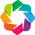

BokehModel(combine_events=True, render_bundle={'docs_json': {'aa069fcf-23de-48d6-aa3b-2381d7673ac8': {'version…

BokehModel(combine_events=True, render_bundle={'docs_json': {'3f3479bc-783e-4d0f-94f8-44330d9f2861': {'version…

In [9]:
h.config["visualize"]["display_images"] = True
h.visualize()

In [17]:
df = viz[1].get_selected_df()
df

,object_id,x,y,coord_ra_data,coord_dec_data,i_cModelmag_data,sersic_index_data,filename_data
0,609789423642490437,1.354579,6.561067,53.482558,-28.301453,19.642923,1.595300,b'cutout_609789423642490437.pt'
1,611254316728076343,1.318687,6.765551,53.286142,-28.058595,19.955418,3.802356,b'cutout_611254316728076343.pt'
2,611254385447548187,1.431999,6.250704,53.236417,-28.132808,18.924511,2.946128,b'cutout_611254385447548187.pt'
3,611255759837084499,1.470011,6.249858,53.103912,-27.804138,18.732122,3.348710,b'cutout_611255759837084499.pt'
4,611254316728081426,1.607965,6.274773,53.301681,-28.022696,19.741258,1.006990,b'cutout_611254316728081426.pt'
...,...,...,...,...,...,...,...,...
189,611253560813831459,2.185509,7.248570,53.480698,-28.258803,19.980119,1.549145,b'cutout_611253560813831459.pt'
190,611253766972265097,2.330206,7.213645,53.086529,-28.191765,19.811427,3.787157,b'cutout_611253766972265097.pt'
191,611254385447552888,1.873576,7.218359,53.120841,-28.060511,19.385824,0.976448,b'cutout_611254385447552888.pt'
192,609781452183189334,2.464077,7.247968,52.988683,-28.464775,19.621866,2.155398,b'cutout_609781452183189334.pt'


In [46]:
data.iloc[0][5].dtype

/tmp/ipykernel_40363/2254504275.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data.iloc[0][5].dtype


dtype('float64')

# Vector DB

In [9]:
h.config["results"]["inference_dir"] = "/mmfs1/gscratch/dirac/aritrag/notebooks/dp1_comcam/results/20260126-131932-infer-gNqG"
h.save_to_database()

[2026-01-26 13:39:55,642 hyrax.data_sets.lsst_dataset:INFO] Did not detect a Butler. You may need to run on the RSP
[2026-01-26 13:39:55,708 hyrax.data_sets.downloaded_lsst_dataset:INFO] Found existing manifest at /mmfs1/gscratch/scrubbed/aritrag/comcam_dp1/ecdfs_objects_public_dp1_34asec_v2/manifest.fits
[2026-01-26 13:39:58,942 hyrax.data_sets.downloaded_lsst_dataset:INFO] Requested bands ['g', 'i', 'r', 'z'] are a subset of available ['g', 'i', 'r', 'u', 'y', 'z']
[2026-01-26 13:39:58,943 hyrax.data_sets.downloaded_lsst_dataset:INFO] Band filtering setup: ['u', 'g', 'r', 'i', 'z', 'y'] -> ['g', 'r', 'i', 'z']
[2026-01-26 13:39:58,943 hyrax.data_sets.downloaded_lsst_dataset:INFO] Tensor indices to extract: [1, 2, 3, 4]
[2026-01-26 13:39:59,135 hyrax.data_sets.downloaded_lsst_dataset:INFO] Current catalog (500 objects)                            is a subset of existing manifest (494820 objects). Using existing manifest                            with filtering for operations.
[2026-01

# Checking The Manifest

In [10]:
from astropy.table import Table                                                                                                                                     
import numpy as np                                                                                                                                                  
                                                                                                                                                                  
# Load the manifest                                                                                                                                                 
manifest = Table.read('/mmfs1/gscratch/scrubbed/aritrag/comcam_dp1/ecdfs_objects_public_dp1_34asec_v2/manifest.fits')                                               
                                                                                                                                                                  
# Basic info                                                                                                                                                        
print(f"Total entries: {len(manifest)}")                                                                                                                            
print(f"Columns: {manifest.colnames}") 

Total entries: 494820
Columns: ['objectId', 'coord_ra', 'coord_dec', 'deblend_failed', 'deblend_nChild', 'parentObjectId', 'deblend_tooManyPeaks', 'detect_fromBlend', 'detect_isIsolated', 'ebv', 'footprintArea', 'u_cModel_flag', 'u_cModelFlux', 'u_extendedness', 'g_cModel_flag', 'g_cModelFlux', 'g_extendedness', 'r_cModel_flag', 'r_cModelFlux', 'r_extendedness', 'i_cModel_flag', 'i_cModelFlux', 'i_extendedness', 'z_cModel_flag', 'z_cModelFlux', 'z_extendedness', 'y_cModel_flag', 'y_cModelFlux', 'y_extendedness', 'sersic_index', 'sersic_reff_x', 'sersic_reff_y', 'sersic_unknown_flag', 'sersic_chisq_reduced', 'sersic_rho', 'u_cModelmag', 'g_cModelmag', 'r_cModelmag', 'i_cModelmag', 'z_cModelmag', 'y_cModelmag', 'cutout_shape', 'filename', 'downloaded_bands']


In [11]:
manifest

objectId,coord_ra,coord_dec,deblend_failed,deblend_nChild,parentObjectId,deblend_tooManyPeaks,detect_fromBlend,detect_isIsolated,ebv,footprintArea,u_cModel_flag,u_cModelFlux,u_extendedness,g_cModel_flag,g_cModelFlux,g_extendedness,r_cModel_flag,r_cModelFlux,r_extendedness,i_cModel_flag,i_cModelFlux,i_extendedness,z_cModel_flag,z_cModelFlux,z_extendedness,y_cModel_flag,y_cModelFlux,y_extendedness,sersic_index,sersic_reff_x,sersic_reff_y,sersic_unknown_flag,sersic_chisq_reduced,sersic_rho,u_cModelmag,g_cModelmag,r_cModelmag,i_cModelmag,z_cModelmag,y_cModelmag,cutout_shape,filename,downloaded_bands
int64,float64,float64,bool,int32,int64,bool,bool,bool,float32,int32,bool,float32,float32,bool,float32,float32,bool,float32,float32,bool,float32,float32,bool,float32,float32,bool,float32,float32,float32,float32,float32,bool,float32,float32,float64,float64,float64,float64,float64,float64,int64[3],bytes50,bytes20
611253423374860292,53.847643305772586,-28.185901959949895,False,1,0,False,False,True,0.009602884,92,True,--,--,False,30.87318,--,False,90.56422,--,False,951.2637,0.0,True,--,--,True,--,--,1.0,2.9240344,2.946045,False,0.74777615,-0.5,--,27.676112196097,26.50767403529042,23.954313343164955,--,--,6 .. 170,cutout_611253423374860292.pt,"u,g,r,i,y"
611253423374860326,53.8442078563098,-28.240347282347436,False,1,0,False,False,True,0.009545375,692,False,5834.004,--,False,8672.74,1.0,False,12874.49,1.0,True,--,--,True,--,--,True,--,--,--,--,--,False,--,--,21.98514883334578,21.554674775753856,21.12574051688865,--,--,--,6 .. 170,cutout_611253423374860326.pt,"u,g,r,i,y"
611253423374860329,53.85817964779943,-28.238673336172234,False,1,0,False,False,True,0.009794378,196,True,--,--,False,272.22565,--,False,787.4923,0.0,True,--,--,True,--,--,True,--,--,1.0,2.5566692,4.49701,False,0.7563415,0.5,--,25.312743025716422,24.159449819072535,--,--,--,6 .. 170,cutout_611253423374860329.pt,"u,g,r,i,y"
611253423374860330,53.853710737351285,-28.237599235196424,False,1,0,False,False,True,0.009716182,126,False,-412.9406,--,False,175.51195,--,False,653.1329,--,True,--,--,True,--,--,True,--,--,1.0,1.1719633,2.0518098,False,0.74116147,0.36332494,--,25.78929890839777,24.36256176414499,--,--,--,6 .. 169,cutout_611253423374860330.pt,"u,g,r,i,y"
611253423374860331,53.85497007948271,-28.237370033563252,False,1,0,False,False,True,0.009739031,144,False,661.3167,--,False,272.5051,--,False,765.6745,--,True,--,--,True,--,--,True,--,--,1.1387815,4.190338,1.6821495,False,0.7016322,-0.51745784,24.34904187869973,25.31162904994197,24.189955163962832,--,--,--,6 .. 169,cutout_611253423374860331.pt,"u,g,r,i,y"
611253423374860333,53.86663822738622,-28.233376128331304,False,1,0,False,False,True,0.00995609,271,True,--,--,False,347.23898,--,False,1464.221,1.0,True,--,--,True,--,--,True,--,--,1.0048777,1.1350249,8.059592,False,0.69045824,0.21901971,--,25.04849443284698,23.48604908324591,--,--,--,6 .. 170,cutout_611253423374860333.pt,"u,g,r,i,y"
611253423374860335,53.86912296813081,-28.232791221811297,False,1,0,False,False,True,0.00999846,135,True,--,--,True,--,--,False,911.41077,--,True,--,--,True,--,--,True,--,--,1.0167845,2.0761855,2.0342307,False,0.89794755,-0.00079591223,--,--,24.000780235662127,--,--,--,6 .. 169,cutout_611253423374860335.pt,"u,g,r,i,y"
611253423374860336,53.86611303102019,-28.2325369035643,False,1,0,False,False,True,0.0099465,154,True,--,--,False,266.70087,--,False,731.0957,0.0,True,--,--,True,--,--,True,--,--,1.020212,1.5915452,2.3467014,False,0.7198278,-0.5014042,--,25.335004554729114,24.24013004370915,--,--,--,6 .. 170,cutout_611253423374860336.pt,"u,g,r,i,y"
611253423374860337,53.86860964607281,-28.231350186927244,False,1,0,False,False,True,0.009988726,476,True,--,--,True,--,--,False,3208.2441,1.0,True,--,--,True,--,--,True,--,--,2.5395896,9.023139,6.320562,False,0.65104157,0.9377568,--,--,22.634397097868614,--,--,--,6 .. 169,cutout_611253423374860337.pt,"u,g,r,i,y"


# 3D Viz

In [10]:
h.config["results"]["inference_dir"] = "/mmfs1/gscratch/dirac/aritrag/notebooks/dp1_comcam/results/20251112-222613-infer-Xrqa"
h.config["umap"]["UMAP"]["n_components"] = 3
h.umap()

[2025-11-13 17:28:10,745 hyrax.data_sets.lsst_dataset:INFO] Did not detect a Butler. You may need to run on the RSP
[2025-11-13 17:28:10,769 hyrax.data_sets.downloaded_lsst_dataset:INFO] Found existing manifest at /mmfs1/gscratch/scrubbed/aritrag/comcam_dp1/ecdfs_objects_public_dp1_34asec_v2/manifest.fits
[2025-11-13 17:28:11,288 hyrax.data_sets.downloaded_lsst_dataset:INFO] Requested bands match available bands exactly, no filtering needed
[2025-11-13 17:28:11,513 hyrax.data_sets.downloaded_lsst_dataset:INFO] Current catalog (3391 objects)                            is a subset of existing manifest (494820 objects). Using existing manifest                            with filtering for operations.
[2025-11-13 17:28:12,295 hyrax.data_sets.downloaded_lsst_dataset:INFO] Manifest merge completed: 494820 preserved, 0 added
[2025-11-13 17:28:15,887 hyrax.data_sets.lsst_dataset:INFO] Did not detect a Butler. You may need to run on the RSP
[2025-11-13 17:28:15,910 hyrax.data_sets.downloaded_ls

Creating lower dimensional representation using UMAP::   0%|          | 0/27 [00:00<?, ?it/s]

[2025-11-13 17:28:39,460 hyrax.verbs.umap:INFO] Finished transforming all data through UMAP
[2025-11-13 17:28:39,580 hyrax.data_sets.lsst_dataset:INFO] Did not detect a Butler. You may need to run on the RSP
[2025-11-13 17:28:39,604 hyrax.data_sets.downloaded_lsst_dataset:INFO] Found existing manifest at /mmfs1/gscratch/scrubbed/aritrag/comcam_dp1/ecdfs_objects_public_dp1_34asec_v2/manifest.fits
[2025-11-13 17:28:40,078 hyrax.data_sets.downloaded_lsst_dataset:INFO] Requested bands match available bands exactly, no filtering needed
[2025-11-13 17:28:40,283 hyrax.data_sets.downloaded_lsst_dataset:INFO] Current catalog (3391 objects)                            is a subset of existing manifest (494820 objects). Using existing manifest                            with filtering for operations.
[2025-11-13 17:28:41,084 hyrax.data_sets.downloaded_lsst_dataset:INFO] Manifest merge completed: 494820 preserved, 0 added
[2025-11-13 17:28:44,655 hyrax.data_sets.lsst_dataset:INFO] Did not detect a B

In [10]:
import importlib.util
import sys
from pathlib import Path

In [11]:
# Import the module
spec = importlib.util.spec_from_file_location(
      "save_umap_to_json",
      "/mmfs1/gscratch/dirac/aritrag/repos/hyrax/src/hyrax/3d_viz/save_umap_to_json.py"
  )

In [12]:
save_umap_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(save_umap_module)

In [14]:
results_dir = "/mmfs1/gscratch/dirac/aritrag/notebooks/dp1_comcam/results/20250703-113913-umap-fKV0/"
output_json = "./results/umap-fKV0-v2.json"
fits_table_path = "/mmfs1/gscratch/dirac/aritrag/comcam_dp1/catalogs/eaabdm_20.fits"
columns_to_include = ["g_cModelmag","r_cModelmag","i_cModelmag","z_cModelmag", "y_cModelmag","filename"]

save_umap_json = save_umap_module.save_umap_json(results_dir = results_dir,output_json=output_json,
                           fits_table_path=fits_table_path,columns_to_include=columns_to_include, id_column="objectId")

Formatting JSON: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 3391/3391 [00:00<00:00, 160425.97it/s]
